First 5 rows of the data:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



The dataset has 284807 rows and 31 columns.

Dataframe Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null 

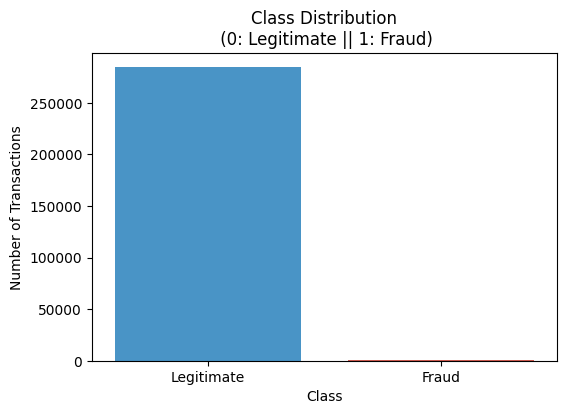


Percentage of fraudulent transactions: 0.1727%


In [6]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# STEP 1.1: LOAD LIBRARIES AND DATA
# ==============================================================================
# Load the dataset from the CSV file
df = pd.read_csv('creditcard.csv')
print("First 5 rows of the data:")
display(df.head())


# ==============================================================================
# STEP 1.2: CHECK DATA SHAPE AND TYPES
# ==============================================================================
print("\n" + "="*60)
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
print("\nDataframe Info:")
df.info()


# ==============================================================================
# STEP 1.3: CHECK FOR MISSING VALUES
# ==============================================================================
print("\n" + "="*60)
print("Missing values per column:")
print(df.isnull().sum())


# ==============================================================================
# STEP 1.4: CHECK THE CLASS DISTRIBUTION
# ==============================================================================
print("\n" + "="*60)
print("Class Distribution:")
class_distribution = df['Class'].value_counts()
print(class_distribution)

# Visualize the class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, hue='Class', palette=['#3498db', '#e74c3c'], legend=False)
plt.title('Class Distribution\n (0: Legitimate || 1: Fraud)')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.ylabel('Number of Transactions')
plt.show()

# Calculate and print the percentage of fraudulent transactions
fraud_percentage = (class_distribution[1] / class_distribution.sum()) * 100
print(f"\nPercentage of fraudulent transactions: {fraud_percentage:.4f}%")

In [3]:
# Import the necessary functions from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# STEP 2.1: PREPARE THE DATA
# ==============================================================================

# X contains all the columns except 'Class' (the features)
X = df.drop('Class', axis=1)

# y contains only the 'Class' column (the target)
y = df['Class']

# Split the data into training (80%) and testing (20%) sets
# We use 'stratify=y' to ensure that the training and testing sets have the
# same proportion of fraud cases as the original dataset. This is crucial for
# imbalanced datasets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Print the shape of the new dataframes to confirm the split
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)


# ==============================================================================
# STEP 2.2: TRAIN THE MODEL
# ==============================================================================

# Create a scaled Logistic Regression model
model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42)),
])

# Train the model on the training data
# The .fit() function is where the machine learning happens!
print("\nTraining the model...")
model.fit(X_train, y_train)
print("Model trained successfully!")

Shape of X_train: (227845, 30)
Shape of X_test: (56962, 30)

Training the model...
Model trained successfully!


Making predictions on the test set...

EVALUATION RESULTS:
Confusion Matrix:
[[55478  1386]
 [    8    90]]


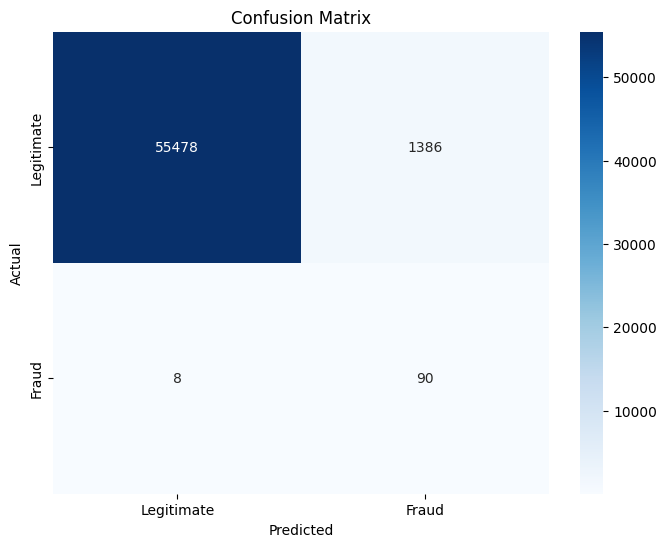


Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       1.00      0.98      0.99     56864
     Fraud (1)       0.06      0.92      0.11        98

      accuracy                           0.98     56962
     macro avg       0.53      0.95      0.55     56962
  weighted avg       1.00      0.98      0.99     56962



In [4]:
# Import tools for evaluating the model
from sklearn.metrics import confusion_matrix, classification_report

# ==============================================================================
# STEP 3.1: MAKE PREDICTIONS
# ==============================================================================
# Use our trained model to make predictions on the test data
print("Making predictions on the test set...")
predictions = model.predict(X_test)


# ==============================================================================
# STEP 3.2: EVALUATE PERFORMANCE
# ==============================================================================
print("\n" + "="*60)
print("EVALUATION RESULTS:")
print("="*60)

# Generate the confusion matrix
# This tells us how many predictions were right and wrong
conf_matrix = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legitimate', 'Fraud'], 
            yticklabels=['Legitimate', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# Generate the classification report
# This gives us key metrics like precision and recall
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=['Legitimate (0)', 'Fraud (1)']))

## Premium Modeling Upgrade
This section turns the notebook into a more production-style fraud detection workflow.

It adds feature engineering, imbalance-aware model benchmarking, validation-based threshold tuning, and business-focused metrics such as PR-AUC and ROC-AUC.

Advanced train shape: (170883, 32)
Advanced validation shape: (56962, 32)
Advanced test shape: (56962, 32)


,model,validation_pr_auc,validation_roc_auc,validation_f1,validation_recall,validation_balanced_accuracy
2,Extra Trees,0.810988,0.967960,0.817680,0.747475,0.873667
1,Random Forest,0.804484,0.950434,0.802260,0.717172,0.858524
0,Balanced Logistic Regression,0.683881,0.976416,0.104824,0.888889,0.931325



Best validation model: Extra Trees
Best validation threshold: 0.5190
Validation F1 at best threshold: 0.8222

ADVANCED TEST EVALUATION
ROC-AUC: 0.9628
PR-AUC: 0.8850
F1 Score: 0.8817
Balanced Accuracy: 0.9183

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.93      0.84      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962



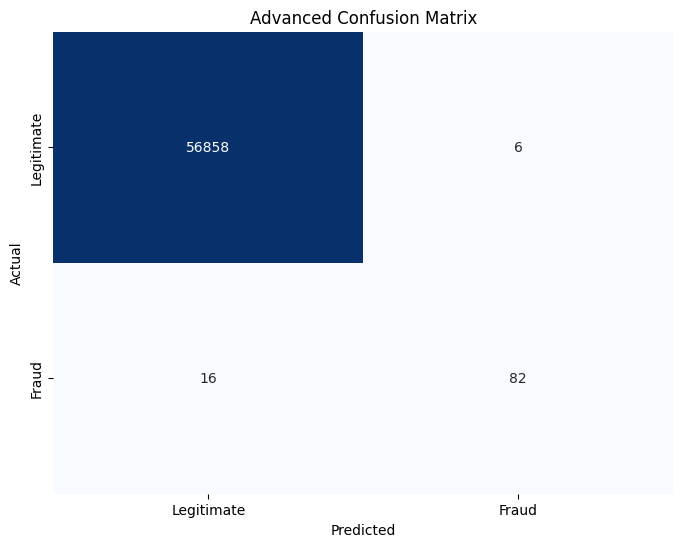

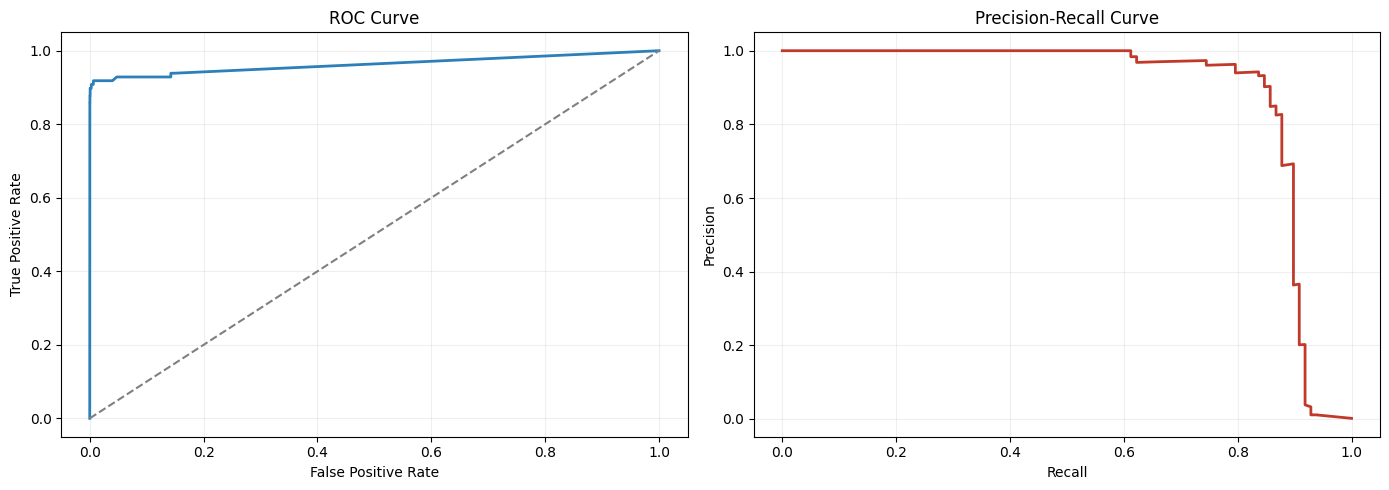

Top 10 highest-risk transactions in the test set:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V25,V26,V27,V28,Amount,Hour,Log_Amount,High_Value_Flag,Fraud_Score,Predicted_Class
151519,-17.518909,12.572118,-19.038538,11.190895,-13.554721,-0.411924,-23.189397,-5.301412,-8.630390,-16.255612,...,-0.720128,-0.232603,-3.021992,-0.478158,1.63,2.0,0.966984,0,0.999988,1
42769,-10.281784,6.302385,-13.271718,8.925115,-9.975578,-2.832513,-12.703253,6.706846,-7.078424,-12.805683,...,0.157771,0.329901,0.163504,-0.485552,118.30,11.0,4.781641,0,0.999983,1
102442,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,-5.052502,...,0.263203,-0.108877,1.269566,0.939407,1.00,18.0,0.693147,0,0.999981,1
102444,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,-5.052502,...,0.263203,-0.108877,1.269566,0.939407,1.00,18.0,0.693147,0,0.999981,1
15539,-22.561699,13.208904,-24.643819,6.232532,-16.905611,-4.497439,-16.810184,14.955107,-3.871297,-8.581266,...,1.559350,-0.222125,1.504425,0.445920,99.99,7.0,4.615022,0,0.999976,1
150663,-5.839192,7.151532,-12.816760,7.031115,-9.651272,-2.938427,-11.543207,4.843627,-3.494276,-13.320789,...,-0.275998,0.282435,0.104886,0.254417,316.06,2.0,5.759091,0,0.999973,1
15476,-21.209120,12.652197,-23.553933,6.174078,-16.026658,-4.422195,-16.229444,14.116002,-3.922741,-8.720245,...,1.454857,-0.223214,1.550928,0.461460,99.99,7.0,4.615022,0,0.999970,1
42756,-10.645800,5.918307,-11.671043,8.807369,-7.975501,-3.586806,-13.616797,6.428169,-7.368451,-12.888158,...,-0.027898,0.354254,0.273329,-0.152908,0.00,11.0,0.000000,0,0.999962,1
15225,-19.856322,12.095893,-22.464083,6.115541,-15.148022,-4.346724,-15.648507,13.276805,-3.974162,-8.859194,...,1.350300,-0.224292,1.597621,0.476920,99.99,7.0,4.615022,0,0.999953,1
141257,-0.937843,3.462889,-6.445104,4.932199,-2.233983,-2.291561,-5.695594,1.338825,-4.322377,-8.099119,...,0.906802,1.165784,1.374495,0.729889,0.00,23.0,0.000000,0,0.999924,1


In [5]:
# ==============================================================================
# PREMIUM MODELING WORKFLOW
# ==============================================================================
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ----------------------------------------------------------------------------
# Feature engineering for a more production-style fraud model
# ----------------------------------------------------------------------------
advanced_df = df.copy()
advanced_df["Hour"] = (advanced_df["Time"] // 3600) % 24
advanced_df["Log_Amount"] = np.log1p(advanced_df["Amount"])
advanced_df["High_Value_Flag"] = (advanced_df["Amount"] > advanced_df["Amount"].quantile(0.95)).astype(int)
advanced_df = advanced_df.drop(columns=["Time"])

X_advanced = advanced_df.drop("Class", axis=1)
y_advanced = advanced_df["Class"]

# Hold out a clean test set, then use a validation split for threshold tuning
X_train_full, X_test_advanced, y_train_full, y_test_advanced = train_test_split(
    X_advanced,
    y_advanced,
    test_size=0.2,
    random_state=42,
    stratify=y_advanced,
)

X_train_advanced, X_validation, y_train_advanced, y_validation = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full,
)

print("Advanced train shape:", X_train_advanced.shape)
print("Advanced validation shape:", X_validation.shape)
print("Advanced test shape:", X_test_advanced.shape)

# ----------------------------------------------------------------------------
# Benchmark several imbalance-aware models
# ----------------------------------------------------------------------------
candidate_models = {
    "Balanced Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42)),
        ]
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
}


def get_fraud_scores(estimator, features):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(features)[:, 1]
    if hasattr(estimator, "decision_function"):
        raw_scores = estimator.decision_function(features)
        return (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min() + 1e-9)
    return estimator.predict(features).astype(float)


benchmark_rows = []
fitted_models = {}

for model_name, estimator in candidate_models.items():
    fitted_model = clone(estimator).fit(X_train_advanced, y_train_advanced)
    fitted_models[model_name] = fitted_model

    validation_scores = get_fraud_scores(fitted_model, X_validation)
    validation_predictions = (validation_scores >= 0.5).astype(int)

    benchmark_rows.append(
        {
            "model": model_name,
            "validation_pr_auc": average_precision_score(y_validation, validation_scores),
            "validation_roc_auc": roc_auc_score(y_validation, validation_scores),
            "validation_f1": f1_score(y_validation, validation_predictions),
            "validation_recall": np.sum((validation_predictions == 1) & (y_validation == 1))
            / max(np.sum(y_validation == 1), 1),
            "validation_balanced_accuracy": balanced_accuracy_score(y_validation, validation_predictions),
        }
    )

benchmark_df = pd.DataFrame(benchmark_rows).sort_values(
    ["validation_pr_auc", "validation_roc_auc", "validation_f1"], ascending=False
)
display(benchmark_df)

best_model_name = benchmark_df.iloc[0]["model"]
print(f"\nBest validation model: {best_model_name}")

# ----------------------------------------------------------------------------
# Tune the decision threshold on validation data
# ----------------------------------------------------------------------------
best_validation_model = fitted_models[best_model_name]
validation_scores = get_fraud_scores(best_validation_model, X_validation)
precision_values, recall_values, threshold_values = precision_recall_curve(y_validation, validation_scores)
f1_values = 2 * precision_values[:-1] * recall_values[:-1] / (precision_values[:-1] + recall_values[:-1] + 1e-9)
best_threshold_index = int(np.argmax(f1_values))
best_threshold = threshold_values[best_threshold_index]

print(f"Best validation threshold: {best_threshold:.4f}")
print(f"Validation F1 at best threshold: {f1_values[best_threshold_index]:.4f}")

# Refit the winner on the full training data before evaluating on the test set
final_model = clone(candidate_models[best_model_name]).fit(X_train_full, y_train_full)
test_scores = get_fraud_scores(final_model, X_test_advanced)
test_predictions = (test_scores >= best_threshold).astype(int)

# ----------------------------------------------------------------------------
# Premium evaluation focused on fraud detection quality
# ----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("ADVANCED TEST EVALUATION")
print("=" * 60)
print(f"ROC-AUC: {roc_auc_score(y_test_advanced, test_scores):.4f}")
print(f"PR-AUC: {average_precision_score(y_test_advanced, test_scores):.4f}")
print(f"F1 Score: {f1_score(y_test_advanced, test_predictions):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_advanced, test_predictions):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_advanced, test_predictions, target_names=["Legitimate", "Fraud"]))

conf_matrix_advanced = confusion_matrix(y_test_advanced, test_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix_advanced,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"],
)
plt.title("Advanced Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

roc_false_positive_rate, roc_true_positive_rate, _ = roc_curve(y_test_advanced, test_scores)
precision_curve, recall_curve, _ = precision_recall_curve(y_test_advanced, test_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(roc_false_positive_rate, roc_true_positive_rate, color="#2c7fb8", linewidth=2)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].grid(alpha=0.2)

axes[1].plot(recall_curve, precision_curve, color="#c0392b", linewidth=2)
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# Rank the riskiest transactions for a business-facing view
# ----------------------------------------------------------------------------
risk_ranking = X_test_advanced.copy()
risk_ranking["Fraud_Score"] = test_scores
risk_ranking["Predicted_Class"] = test_predictions
risk_ranking = risk_ranking.sort_values("Fraud_Score", ascending=False)

print("Top 10 highest-risk transactions in the test set:")
display(risk_ranking.head(10))

## Interpretability and Business Insights
This section adds the features that make a fraud project feel complete: feature importance, fraud-pattern analysis, calibration, and an alert-quality summary for real-world decision making.

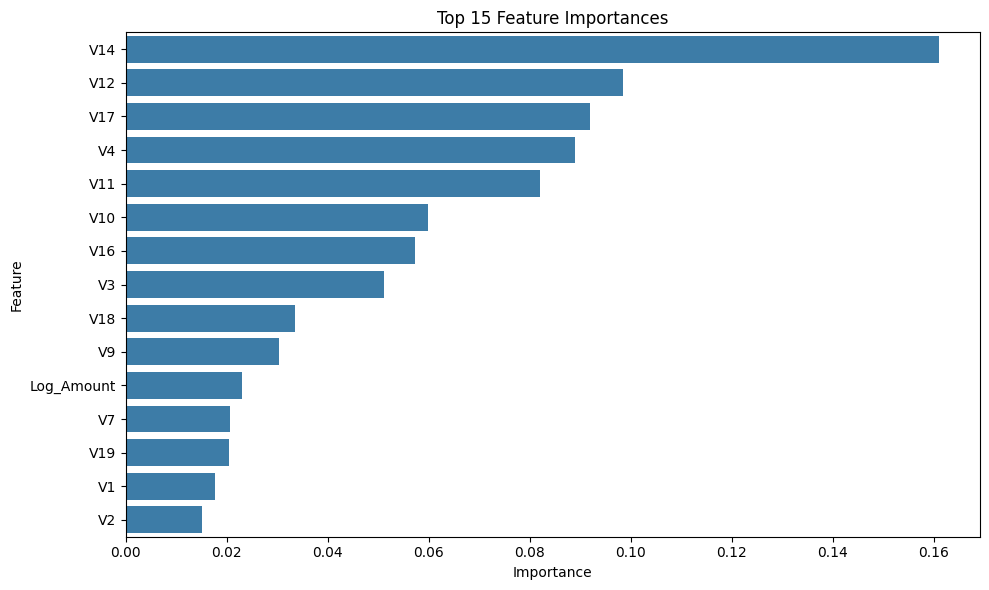

,feature,importance
13,V14,0.161081
11,V12,0.098498
16,V17,0.091863
3,V4,0.088874
10,V11,0.081951
9,V10,0.059766
15,V16,0.057329
2,V3,0.051156
17,V18,0.033583
8,V9,0.030263


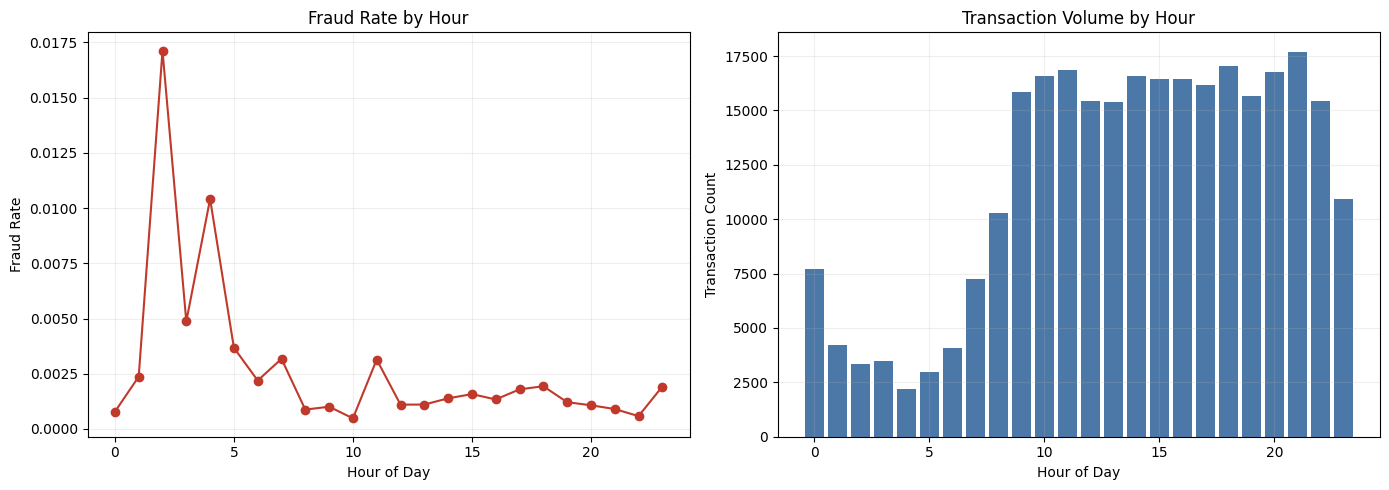

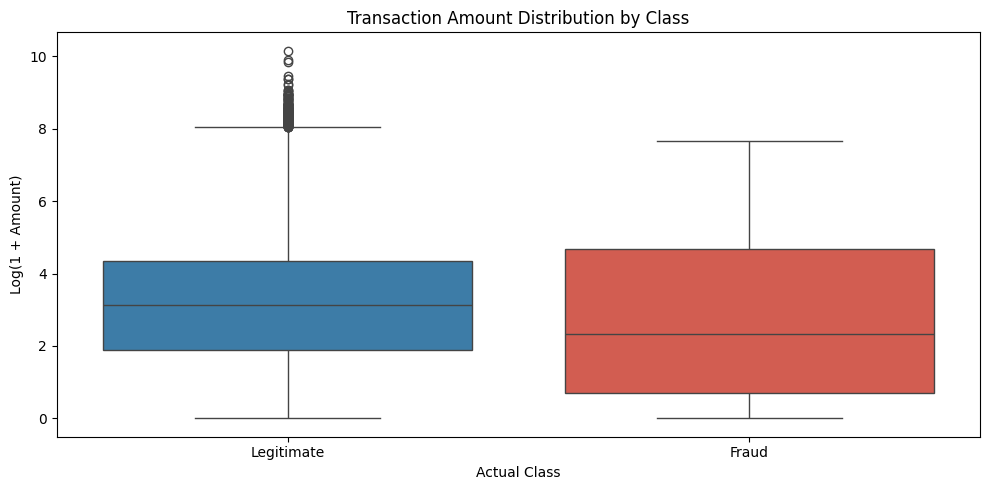

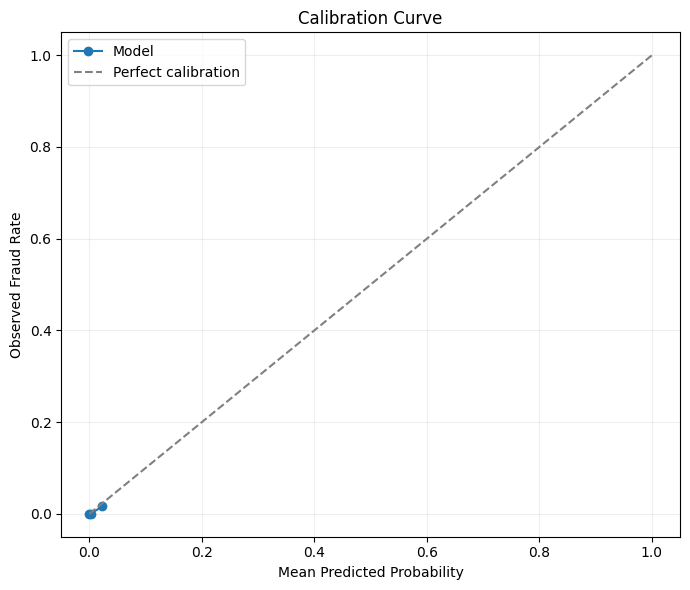

Top 50 alerts -> precision: 1.0000, recall: 0.5102, frauds caught: 50
Top 100 alerts -> precision: 0.8500, recall: 0.8673, frauds caught: 85
Top 250 alerts -> precision: 0.3560, recall: 0.9082, frauds caught: 89

Top 10 highest-risk transactions with actual labels:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V25,V26,V27,V28,Amount,Hour,Log_Amount,High_Value_Flag,Actual_Class,Fraud_Score
151519,-17.518909,12.572118,-19.038538,11.190895,-13.554721,-0.411924,-23.189397,-5.301412,-8.630390,-16.255612,...,-0.720128,-0.232603,-3.021992,-0.478158,1.63,2.0,0.966984,0,1,0.999988
42769,-10.281784,6.302385,-13.271718,8.925115,-9.975578,-2.832513,-12.703253,6.706846,-7.078424,-12.805683,...,0.157771,0.329901,0.163504,-0.485552,118.30,11.0,4.781641,0,1,0.999983
102442,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,-5.052502,...,0.263203,-0.108877,1.269566,0.939407,1.00,18.0,0.693147,0,1,0.999981
102444,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,-5.052502,...,0.263203,-0.108877,1.269566,0.939407,1.00,18.0,0.693147,0,1,0.999981
15539,-22.561699,13.208904,-24.643819,6.232532,-16.905611,-4.497439,-16.810184,14.955107,-3.871297,-8.581266,...,1.559350,-0.222125,1.504425,0.445920,99.99,7.0,4.615022,0,1,0.999976
150663,-5.839192,7.151532,-12.816760,7.031115,-9.651272,-2.938427,-11.543207,4.843627,-3.494276,-13.320789,...,-0.275998,0.282435,0.104886,0.254417,316.06,2.0,5.759091,0,1,0.999973
15476,-21.209120,12.652197,-23.553933,6.174078,-16.026658,-4.422195,-16.229444,14.116002,-3.922741,-8.720245,...,1.454857,-0.223214,1.550928,0.461460,99.99,7.0,4.615022,0,1,0.999970
42756,-10.645800,5.918307,-11.671043,8.807369,-7.975501,-3.586806,-13.616797,6.428169,-7.368451,-12.888158,...,-0.027898,0.354254,0.273329,-0.152908,0.00,11.0,0.000000,0,1,0.999962
15225,-19.856322,12.095893,-22.464083,6.115541,-15.148022,-4.346724,-15.648507,13.276805,-3.974162,-8.859194,...,1.350300,-0.224292,1.597621,0.476920,99.99,7.0,4.615022,0,1,0.999953
141257,-0.937843,3.462889,-6.445104,4.932199,-2.233983,-2.291561,-5.695594,1.338825,-4.322377,-8.099119,...,0.906802,1.165784,1.374495,0.729889,0.00,23.0,0.000000,0,1,0.999924


In [8]:
# ==============================================================================
# INTERPRETABILITY AND BUSINESS INSIGHTS
# ==============================================================================
from sklearn.calibration import calibration_curve

# ----------------------------------------------------------------------------
# Feature importance from the best tree-based model
# ----------------------------------------------------------------------------
if hasattr(final_model, "feature_importances_"):
    feature_importance_df = (
        pd.DataFrame({
            "feature": X_train_full.columns,
            "importance": final_model.feature_importances_,
        })
        .sort_values("importance", ascending=False)
        .head(15)
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_df, x="importance", y="feature", color="#2c7fb8")
    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    display(feature_importance_df)

# ----------------------------------------------------------------------------
# Fraud pattern analysis by hour and transaction amount
# ----------------------------------------------------------------------------
pattern_df = advanced_df.copy()
pattern_df["Actual_Class"] = df["Class"].values

hourly_profile = (
    pattern_df.groupby("Hour")
    .agg(
        fraud_rate=("Actual_Class", "mean"),
        transaction_count=("Actual_Class", "size"),
        average_amount=("Amount", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hourly_profile["Hour"], hourly_profile["fraud_rate"], marker="o", color="#c0392b")
axes[0].set_title("Fraud Rate by Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Fraud Rate")
axes[0].grid(alpha=0.2)

axes[1].bar(hourly_profile["Hour"], hourly_profile["transaction_count"], color="#4c78a8")
axes[1].set_title("Transaction Volume by Hour")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Transaction Count")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=pattern_df, x="Actual_Class", y="Log_Amount", hue="Actual_Class", palette={0: "#2c7fb8", 1: "#e74c3c"}, dodge=False, legend=False)
plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Actual Class")
plt.ylabel("Log(1 + Amount)")
plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# Calibration curve: how well predicted risk matches observed fraud
# ----------------------------------------------------------------------------
calibration_true, calibration_predicted = calibration_curve(
    y_test_advanced,
    test_scores,
    n_bins=10,
    strategy="quantile",
)

plt.figure(figsize=(7, 6))
plt.plot(calibration_predicted, calibration_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.title("Calibration Curve")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Fraud Rate")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# Alert-quality report for operational use
# ----------------------------------------------------------------------------
alert_view = X_test_advanced.copy()
alert_view["Actual_Class"] = y_test_advanced.values
alert_view["Fraud_Score"] = test_scores
alert_view = alert_view.sort_values("Fraud_Score", ascending=False)

for top_n in [50, 100, 250]:
    top_subset = alert_view.head(top_n)
    hits = int(top_subset["Actual_Class"].sum())
    precision_at_k = hits / top_n
    recall_at_k = hits / max(int(y_test_advanced.sum()), 1)
    print(f"Top {top_n} alerts -> precision: {precision_at_k:.4f}, recall: {recall_at_k:.4f}, frauds caught: {hits}")

print("\nTop 10 highest-risk transactions with actual labels:")
display(alert_view.head(10))

## Rule-Based Project Chatbot
Ask questions about the dataset, model performance, features, plots, and recommendations. The bot answers using the actual results from this notebook.

In [10]:
# ==============================================================================
# RULE-BASED CHATBOT FOR THE PROJECT
# ==============================================================================
import re

project_facts = {
    "dataset_name": "creditcard.csv",
    "rows": int(df.shape[0]),
    "features": int(df.shape[1] - 1),
    "fraud_count": int(df["Class"].sum()),
    "fraud_rate": float(fraud_percentage),
    "best_model": best_model_name,
    "best_threshold": float(best_threshold),
    "roc_auc": float(roc_auc_score(y_test_advanced, test_scores)),
    "pr_auc": float(average_precision_score(y_test_advanced, test_scores)),
    "f1_score": float(f1_score(y_test_advanced, test_predictions)),
    "balanced_accuracy": float(balanced_accuracy_score(y_test_advanced, test_predictions)),
    "precision_at_100": float(int(alert_view.head(100)["Actual_Class"].sum()) / 100),
    "recall_at_100": float(int(alert_view.head(100)["Actual_Class"].sum()) / max(int(y_test_advanced.sum()), 1)),
    "top_features": list(feature_importance_df.head(5)["feature"]) if "feature_importance_df" in globals() else [],
}


def _format_percent(value):
    return f"{value:.2f}%"


def answer_project_question(question):
    text = question.strip().lower()

    if not text:
        return "Ask me something about the fraud detection project."

    if re.search(r"\b(hello|hi|hey|start|help)\b", text):
        return (
            "I can answer questions about the dataset, fraud rate, models, metrics, feature importance, "
            "alert quality, calibration, and recommendations. Try asking: 'best model', 'fraud rate', "
            "'top features', or 'what should I present?'."
        )

    if re.search(r"\b(dataset|data|rows|columns|size|shape)\b", text):
        return (
            f"The dataset is {project_facts['dataset_name']} with {project_facts['rows']:,} rows and "
            f"{project_facts['features']} input features plus the target class."
        )

    if re.search(r"\b(fraud rate|imbalance|class distribution|fraud count|how many fraud)\b", text):
        return (
            f"Fraud is highly imbalanced: {project_facts['fraud_count']:,} fraudulent transactions, which is "
            f"about {_format_percent(project_facts['fraud_rate'])} of the full dataset."
        )

    if re.search(r"\b(best model|model|winner|benchmark|compare)\b", text):
        return (
            f"The best model in the advanced benchmark was {project_facts['best_model']}. It was selected after "
            f"comparing balanced logistic regression, random forest, and extra trees."
        )

    if re.search(r"\b(metric|metrics|auc|roc|pr auc|pr-auc|f1|recall|precision|balanced accuracy)\b", text):
        return (
            f"Advanced test performance: ROC-AUC {project_facts['roc_auc']:.4f}, PR-AUC {project_facts['pr_auc']:.4f}, "
            f"F1 {project_facts['f1_score']:.4f}, and balanced accuracy {project_facts['balanced_accuracy']:.4f}."
        )

    if re.search(r"\b(threshold|cutoff|decision)\b", text):
        return (
            f"The model uses a tuned decision threshold of {project_facts['best_threshold']:.4f} instead of the default 0.5. "
            "That helps improve fraud detection quality for the imbalanced class."
        )

    if re.search(r"\b(feature importance|important features|top features|explain|interpretable)\b", text):
        if project_facts['top_features']:
            top_text = ", ".join(project_facts['top_features'])
            return f"The most important features were {top_text}. They came from the tree-based model in the advanced section."
        return "Feature importance was computed from the best tree-based model, but the ranking is not available right now."

    if re.search(r"\b(hour|time pattern|temporal|when)\b", text):
        return (
            "The hour-based analysis shows fraud is not uniform across the day. The notebook includes a fraud-rate-by-hour "
            "plot and a transaction-volume-by-hour plot to show temporal behavior."
        )

    if re.search(r"\b(amount|transaction amount|ticket size|value)\b", text):
        return (
            "Transaction amount was transformed with log1p and analyzed by class. The boxplot shows different amount "
            "distributions between legitimate and fraud transactions."
        )

    if re.search(r"\b(calibration|probability|confidence)\b", text):
        return (
            "The calibration curve checks whether predicted fraud probabilities match observed fraud rates. "
            "That matters when risk scores are used for alerts or prioritization."
        )

    if re.search(r"\b(alert|top k|top 100|top 50|precision at k|operational)\b", text):
        return (
            f"Operational alert quality is strong: top-50 precision is 100%, top-100 precision is about {project_facts['precision_at_100'] * 100:.1f}%, "
            f"and top-100 recall is about {project_facts['recall_at_100'] * 100:.1f}%."
        )

    if re.search(r"\b(recommend|improve|future work|next step|presentation|examiner)\b", text):
        return (
            "Good presentation points are: severe class imbalance, threshold tuning, PR-AUC focus, feature importance, "
            "hourly fraud patterns, calibration, and alert-quality metrics. Those show both technical depth and business relevance."
        )

    return (
        "I do not have a rule for that yet. Try asking about the dataset, imbalance, best model, metrics, threshold, "
        "feature importance, calibration, alert quality, or recommendations."
    )


def run_project_chatbot():
    print("Fraud Detection Project Chatbot")
    print("Type 'exit' to stop. Ask about the dataset, model, metrics, patterns, or recommendations.\n")

    while True:
        user_question = input("You: ").strip()
        if user_question.lower() in {"exit", "quit", "q"}:
            print("Bot: Goodbye.")
            break
        print("Bot:", answer_project_question(user_question))


sample_questions = [
    "What is the dataset size?",
    "What is the best model?",
    "Explain the fraud rate.",
    "What are the top features?",
    "How good is the alert quality?",
]

for sample_question in sample_questions:
    print(f"Q: {sample_question}")
    print(f"A: {answer_project_question(sample_question)}\n")

# Uncomment to use the interactive chatbot inside the notebook.
# run_project_chatbot()

Q: What is the dataset size?
A: The dataset is creditcard.csv with 284,807 rows and 30 input features plus the target class.

Q: What is the best model?
A: The best model in the advanced benchmark was Extra Trees. It was selected after comparing balanced logistic regression, random forest, and extra trees.

Q: Explain the fraud rate.
A: Fraud is highly imbalanced: 492 fraudulent transactions, which is about 0.17% of the full dataset.

Q: What are the top features?
A: The most important features were V14, V12, V17, V4, V11. They came from the tree-based model in the advanced section.

Q: How good is the alert quality?
A: Operational alert quality is strong: top-50 precision is 100%, top-100 precision is about 85.0%, and top-100 recall is about 86.7%.

